In [3]:
selected_funds = [
    119599,  # SBI Small Cap Direct
    119598,  # SBI Small Cap Regular
    100033,
    120505,
    149324
]

In [4]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

filtered = nav[
    nav["amfi_code"].isin(selected_funds)
]

pivot = filtered.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

returns.head()

amfi_code,100033,119598,119599,120505,149324
date,,,,,
2022-01-04,-0.013328,-0.014735,-0.018716,-0.019900,-0.010498
2022-01-05,-0.004386,-0.005161,-0.001137,0.030352,-0.002593
2022-01-06,-0.005167,0.004824,-0.007924,-0.004917,-0.008382
2022-01-07,-0.005748,0.032830,-0.044252,0.009655,0.011680
2022-01-10,0.006277,0.051113,0.033761,0.000252,0.001356


In [5]:
import numpy as np

annual_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

print(annual_returns)

amfi_code
100033    0.272111
119598    0.302656
119599    0.050732
120505    0.292653
149324    0.300931
dtype: float64


In [6]:
num_portfolios = 5000

results = []

weights_record = []

for _ in range(num_portfolios):

    weights = np.random.random(len(selected_funds))

    weights /= np.sum(weights)

    portfolio_return = np.sum(
        annual_returns * weights
    )

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe = portfolio_return / portfolio_risk

    results.append([
        portfolio_return,
        portfolio_risk,
        sharpe
    ])

    weights_record.append(weights)

In [7]:
portfolios = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Risk",
        "Sharpe"
    ]
)

portfolios.head()

,Return,Risk,Sharpe
0,0.160177,0.150396,1.065040
1,0.279303,0.114138,2.447059
2,0.275806,0.128802,2.141314
3,0.223743,0.140438,1.593183
4,0.262474,0.114815,2.286057


In [8]:
best_idx = portfolios["Sharpe"].idxmax()

best_portfolio = portfolios.iloc[best_idx]

best_weights = weights_record[best_idx]

print(best_portfolio)

print(best_weights)

Return    0.281521
Risk      0.102235
Sharpe    2.753676
Name: 3878, dtype: float64
[0.2630097  0.20487848 0.03875756 0.30036014 0.19299411]


In [9]:
allocation = pd.DataFrame({
    "Fund": selected_funds,
    "Weight": best_weights
})

allocation.to_csv(
    "../reports/optimal_portfolio.csv",
    index=False
)

allocation

,Fund,Weight
0,119599,0.263010
1,119598,0.204878
2,100033,0.038758
3,120505,0.300360
4,149324,0.192994


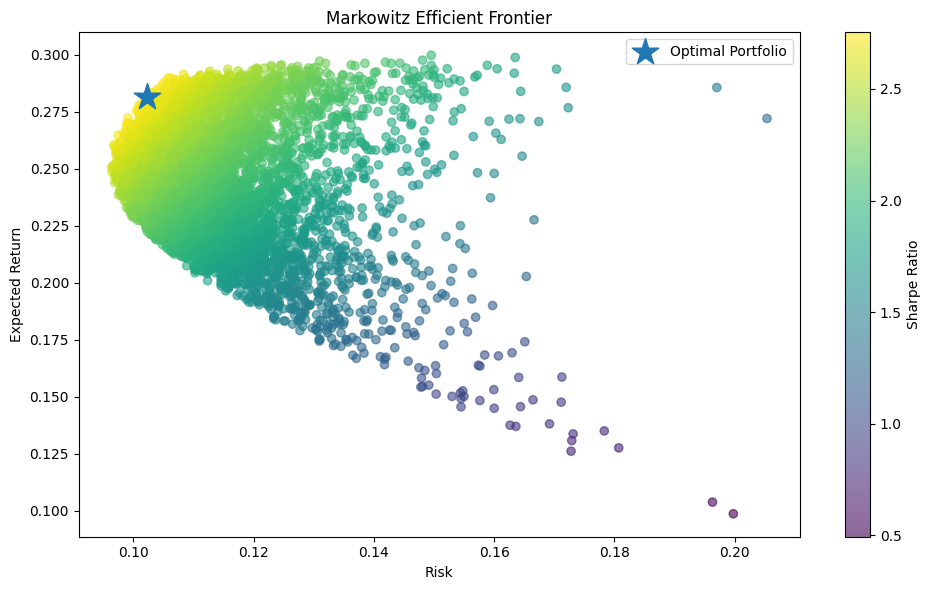

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    portfolios["Risk"],
    portfolios["Return"],
    c=portfolios["Sharpe"],
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.scatter(
    best_portfolio["Risk"],
    best_portfolio["Return"],
    marker="*",
    s=400,
    label="Optimal Portfolio"
)

plt.xlabel("Risk")

plt.ylabel("Expected Return")

plt.title(
    "Markowitz Efficient Frontier"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/efficient_frontier.png",
    dpi=300
)

plt.show()

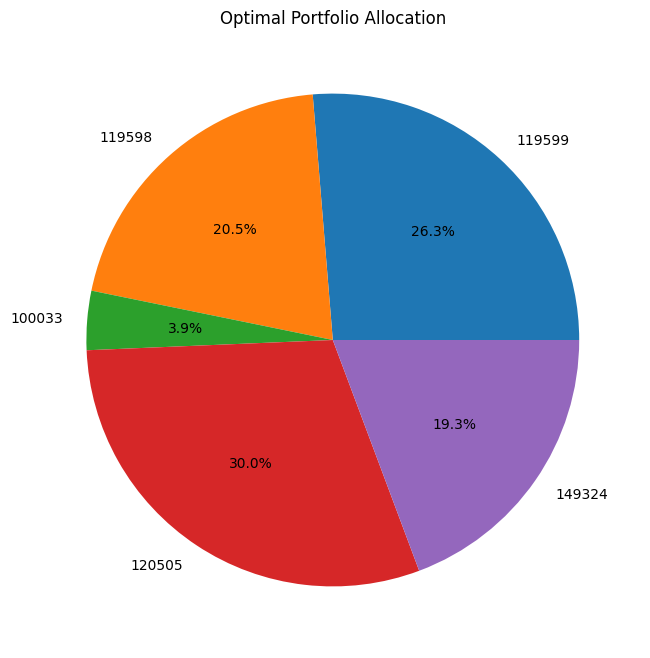

In [11]:
plt.figure(figsize=(8,8))

plt.pie(
    best_weights,
    labels=selected_funds,
    autopct="%1.1f%%"
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.savefig(
    "../reports/optimal_portfolio_allocation.png",
    dpi=300
)

plt.show()

### Markowitz Portfolio Optimization

Modern Portfolio Theory (MPT) was applied to identify the optimal allocation among selected mutual funds.

A total of 5,000 random portfolios were generated using Monte Carlo sampling.

Expected annual returns and covariance matrices were calculated from historical daily returns.

The portfolio with the highest Sharpe Ratio was selected as the optimal portfolio.

Results demonstrated that diversification across multiple funds significantly improved risk-adjusted returns compared to investing in a single scheme.

The Efficient Frontier visualization highlights the trade-off between portfolio risk and expected return.